## Modules & functions import

In [1]:
import os
import sys

In [2]:
sys.path.append("../common_key_functions/")

In [3]:
from constants_configs import MODELS_CONFIGS
from all_plots import plot_log_from_npz

## Training graphs

In [4]:
def plot_logs_networks(networks_names: list[str],
                       all_logs_dir: str,
                       log_filename: str,
                       dataset_name: str | None = "dataset",
                       start_step: int | None = 0,
                       figsize: tuple[int, int] | None = (10,30)):
    for network_name in networks_names:
        network_logs_dir = os.path.join(all_logs_dir, f"inversion_{network_name}_{dataset_name}/")
            
        for log_dir in os.listdir(network_logs_dir):
            log_dir_name_split = log_dir.split("_")
            # n_training_steps = int(log_dir_name_split[1])
            classes_ids = log_dir_name_split[3]
            
            log_path = os.path.join(network_logs_dir, log_dir, log_filename)
            
            if os.path.exists(log_path):
                plot_log_from_npz(
                    log_path,
                    network_name,
                    dataset_name,
                    metric_ids_to_skip=[3],
                    start_step=start_step,
                    classes_ids=classes_ids,
                    figsize=figsize
                )

In [5]:
dataset_dir_imagenet = "/media/user/Hitachi/ILSVRC/Data/CLS-LOC"
dataset_name = "ImageNet"

networks_names = ["convnext_l"] # MODELS_CONFIGS.keys()
all_logs_dir = "inversion_images_logs"
log_filename = "training_log.npz"

### Graphs of complete training

/home/user/Desktop/o-net-experiments/network_inversion/../common_key_functions/all_plots.py:197: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[metric_i].legend()


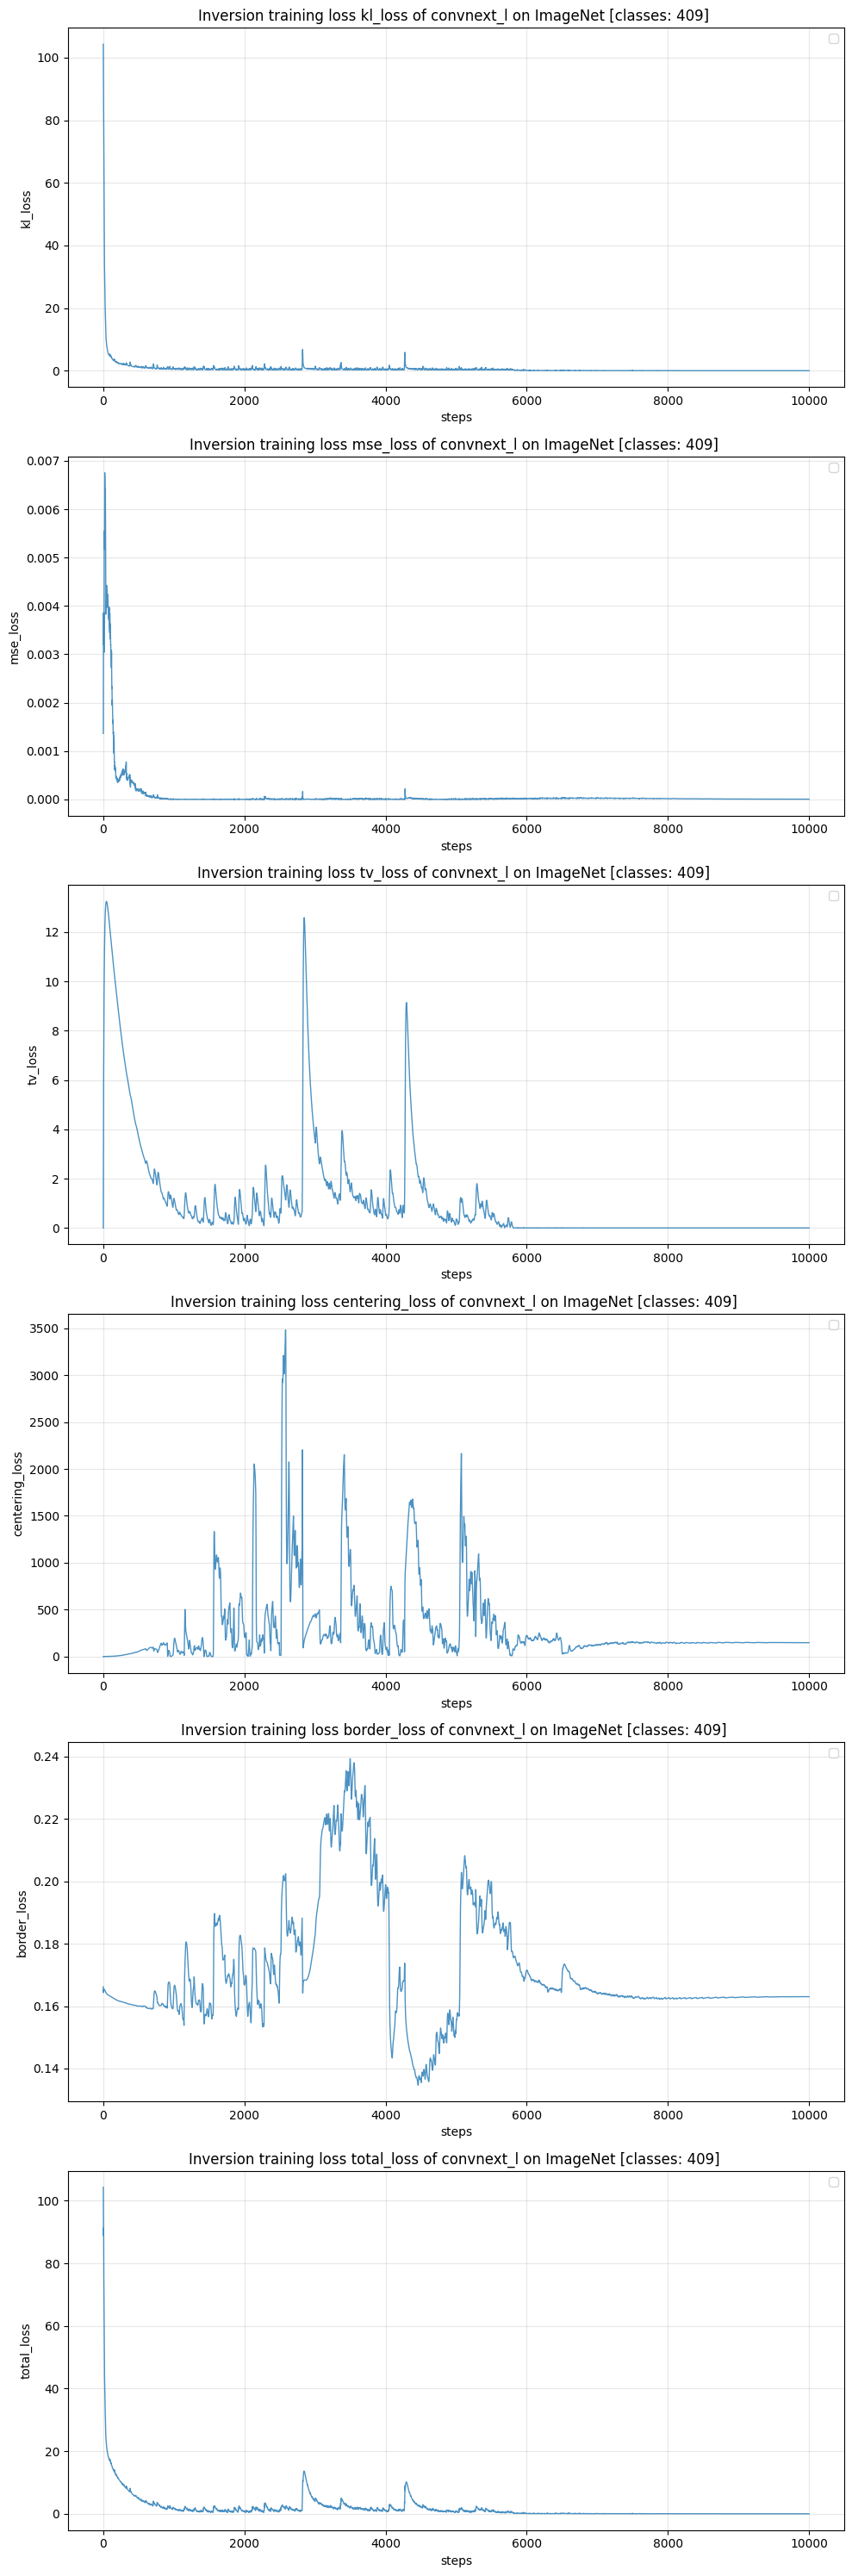

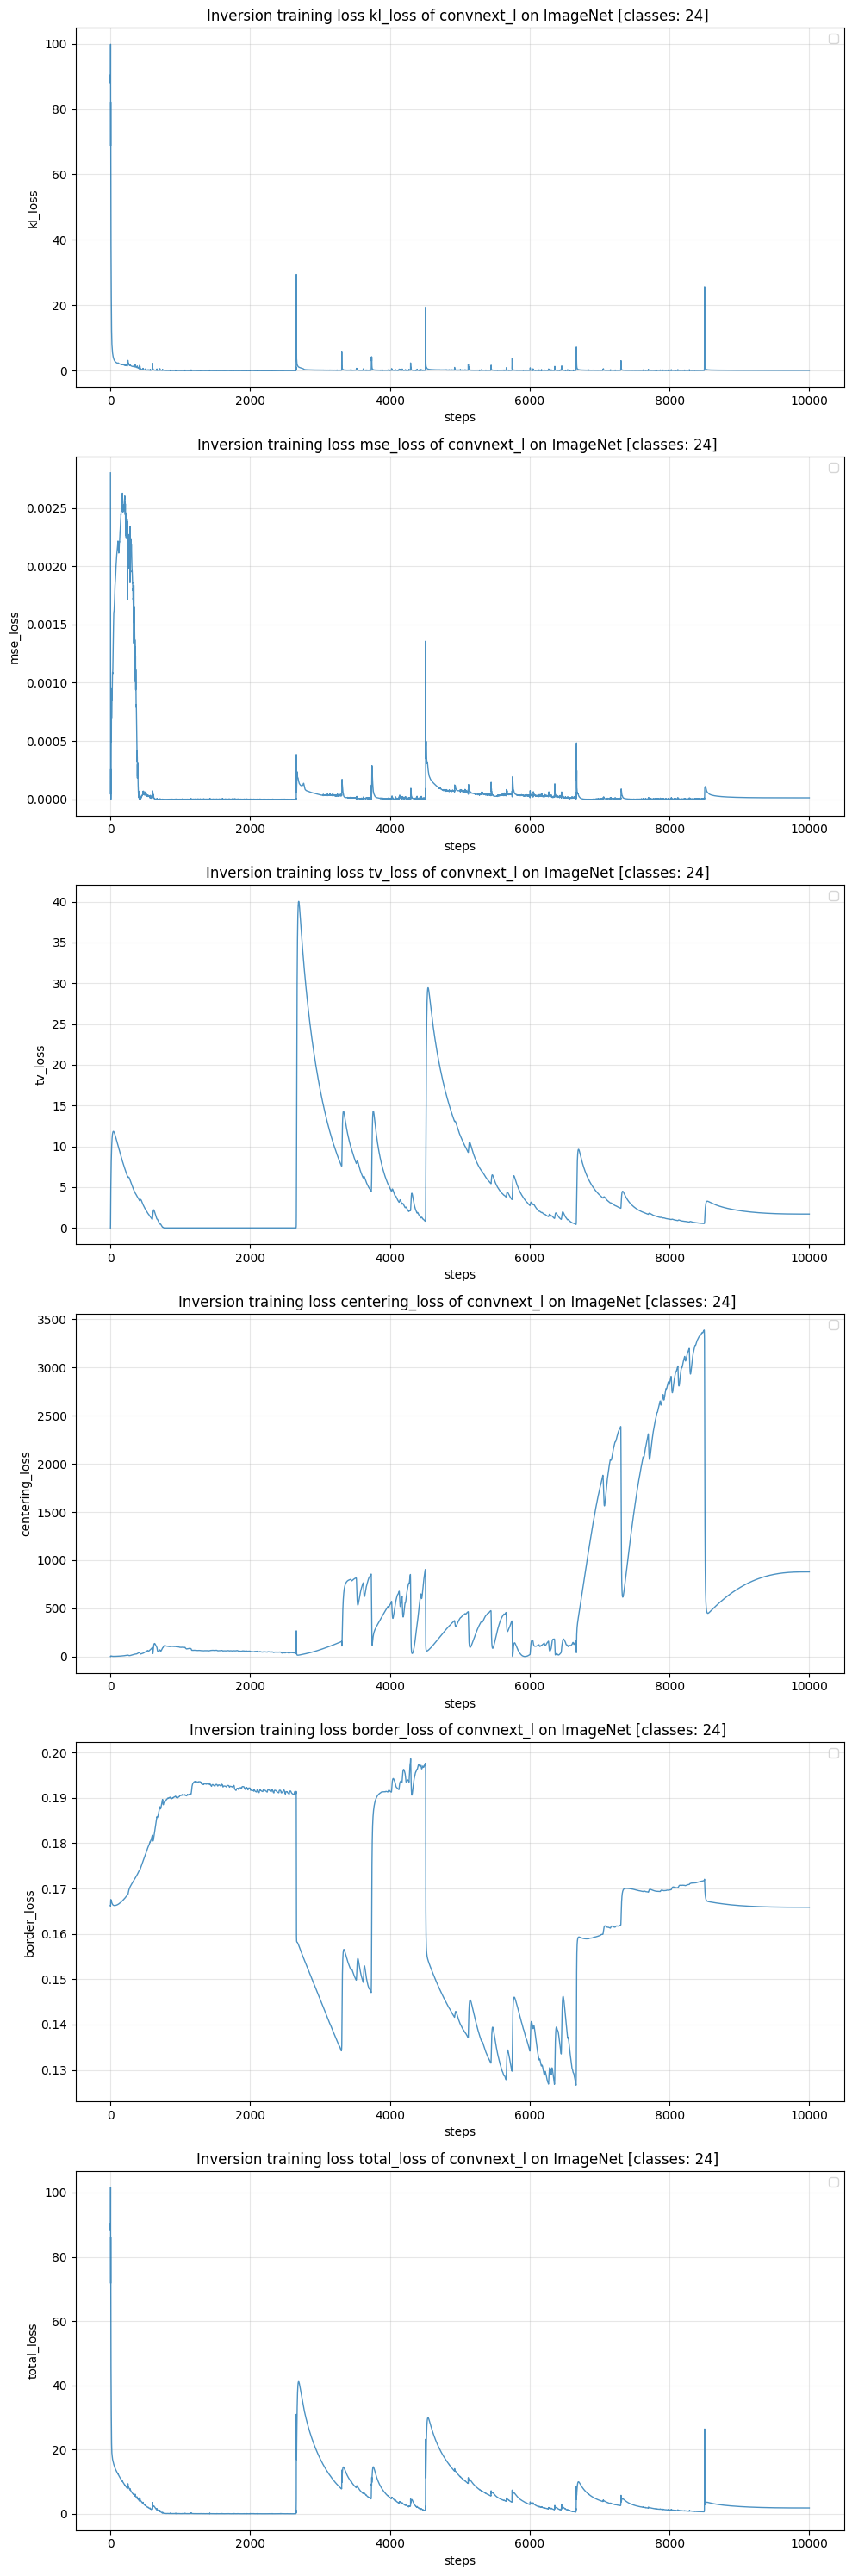

In [6]:
plot_logs_networks(
    networks_names, 
    all_logs_dir, 
    log_filename, 
    dataset_name
)

### Graphs of final training steps (6000 - 10 000)

In [ ]:
plot_logs_networks(
    networks_names, 
    all_logs_dir, 
    log_filename, 
    dataset_name, 
    start_step=6000
)